<a href="https://colab.research.google.com/github/aabyyaann/Practical-Linear-Algebra-for-Data-Science/blob/main/Chapter12_Least_Squares_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 12 — Least Squares Applications

## Tujuan Chapter

Pada chapter ini kita mempelajari beberapa aplikasi nyata dari metode Least Squares yang telah dipelajari pada Chapter 11.

Topik yang dibahas:

1. Prediksi menggunakan regresi linear
2. Hubungan cuaca dan penyewaan sepeda
3. Multicollinearity
4. Regularization
5. Polynomial Regression
6. Grid Search
7. Evaluasi model

Chapter ini menunjukkan bagaimana konsep linear algebra digunakan langsung dalam machine learning dan data science.

# Ringkasan Teori

Pada chapter sebelumnya kita memperoleh solusi least squares:

\[
x=(A^TA)^{-1}A^Tb
\]

Pada chapter ini kita menggunakannya untuk:

- melakukan prediksi
- menangani data yang memiliki noise
- membangun model yang lebih kompleks
- mengurangi overfitting
- memilih parameter terbaik

Semua teknik ini merupakan fondasi machine learning modern.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# 1. Dataset Sederhana

Misalkan kita memiliki data:

- x = temperatur
- y = jumlah penyewaan sepeda

Data berikut hanya simulasi untuk memahami konsep.

In [2]:
temperature = np.array([20,22,24,26,28,30,32,34])
rentals = np.array([100,120,135,150,170,190,205,220])

print("Temperature:")
print(temperature)

print("\nRentals:")
print(rentals)

Temperature:
[20 22 24 26 28 30 32 34]

Rentals:
[100 120 135 150 170 190 205 220]


# 2. Visualisasi Data

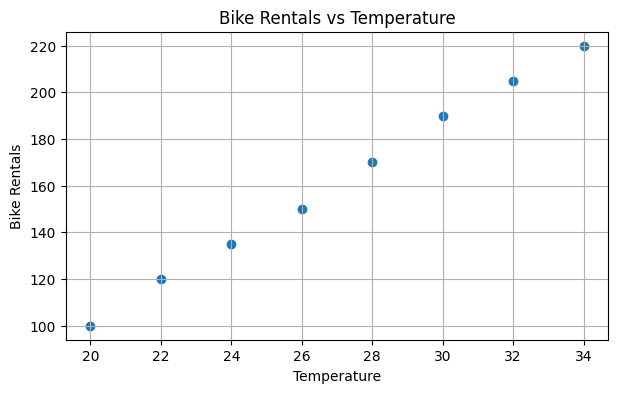

In [3]:
plt.figure(figsize=(7,4))
plt.scatter(temperature,rentals)
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals vs Temperature")
plt.grid(True)
plt.show()

# 3. Membentuk Design Matrix

Model linear:

\[
y=\beta_0+\beta_1x
\]

ditulis dalam bentuk matriks sebagai:

\[
Ax=b
\]

In [4]:
A = np.column_stack([
    np.ones(len(temperature)),
    temperature
])

print(A)

[[ 1. 20.]
 [ 1. 22.]
 [ 1. 24.]
 [ 1. 26.]
 [ 1. 28.]
 [ 1. 30.]
 [ 1. 32.]
 [ 1. 34.]]


# 4. Least Squares Regression

In [5]:
coef, *_ = np.linalg.lstsq(A,rentals,rcond=None)

print("Intercept =", coef[0])
print("Slope     =", coef[1])

Intercept = -71.7857142857142
Slope     = 8.630952380952381


# 5. Prediksi Model

In [6]:
prediction = A @ coef

print(prediction)

[100.8333 118.0952 135.3571 152.619  169.881  187.1429 204.4048 221.6667]


# Visualisasi Hasil Fitting

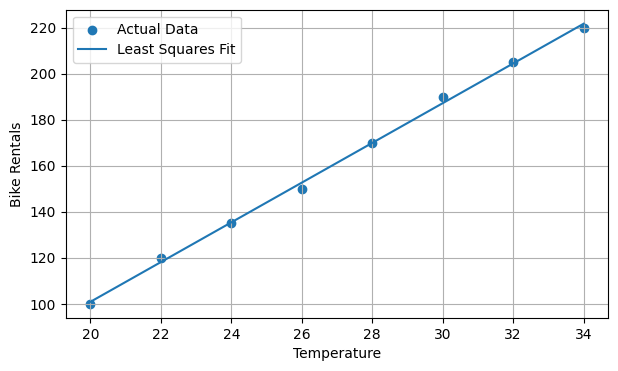

In [7]:
plt.figure(figsize=(7,4))

plt.scatter(
    temperature,
    rentals,
    label="Actual Data"
)

plt.plot(
    temperature,
    prediction,
    label="Least Squares Fit"
)

plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.legend()
plt.grid(True)
plt.show()

# 6. Residual

Residual adalah:

\[
r=y-\hat y
\]

Residual menunjukkan error prediksi model.

In [8]:
residual = rentals - prediction

print(residual)

[-0.8333  1.9048 -0.3571 -2.619   0.119   2.8571  0.5952 -1.6667]


# 7. Sum Squared Error (SSE)

Least Squares meminimalkan:

\[
SSE=\sum r_i^2
\]

In [9]:
sse = np.sum(residual**2)

print("SSE =", sse)

SSE = 22.619047619047652


# 8. Mean Squared Error (MSE)

MSE adalah rata-rata kuadrat error.

In [10]:
mse = np.mean(residual**2)

print("MSE =", mse)

MSE = 2.8273809523809565


# 9. Koefisien Determinasi (R²)

R² mengukur seberapa baik model menjelaskan data.

Nilai:

- 1 = sempurna
- 0 = tidak menjelaskan data

In [11]:
ss_total = np.sum(
    (rentals - np.mean(rentals))**2
)

ss_residual = np.sum(
    residual**2
)

r2 = 1 - (ss_residual/ss_total)

print("R² =", r2)

R² = 0.9981958885249015


# 10. Multicollinearity

Multicollinearity terjadi ketika beberapa fitur memiliki hubungan yang sangat kuat.

Hal ini menyebabkan:

- parameter tidak stabil
- interpretasi model menjadi sulit
- error estimasi meningkat

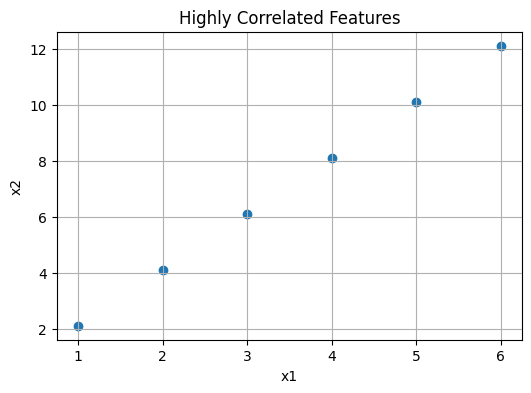

In [12]:
x1 = np.array([1,2,3,4,5,6])
x2 = 2*x1 + 0.1

plt.figure(figsize=(6,4))
plt.scatter(x1,x2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Highly Correlated Features")
plt.grid(True)
plt.show()

## Korelasi Antar Fitur

In [13]:
corr = np.corrcoef(x1,x2)

print(corr)

[[1. 1.]
 [1. 1.]]


# Interpretasi

Nilai korelasi mendekati:

\[
1
\]

menunjukkan adanya multicollinearity yang sangat kuat.

# 11. Regularization

Regularization digunakan untuk:

- mengurangi overfitting
- mengatasi multicollinearity
- menghasilkan model yang lebih stabil

Salah satu metode paling populer adalah Ridge Regression.

In [14]:
A = np.column_stack([
    np.ones(len(temperature)),
    temperature
])

b = rentals

## Ridge Formula

\[
x=(A^TA+\lambda I)^{-1}A^Tb
\]

Parameter:

\[
\lambda
\]

mengontrol kekuatan regularisasi.

In [15]:
lam = 10

I = np.eye(A.shape[1])

ridge_coef = np.linalg.inv(
    A.T@A + lam*I
) @ (A.T@b)

print(ridge_coef)

[-1.3585  6.0854]


# Perbandingan Least Squares vs Ridge

In [16]:
ls_coef, *_ = np.linalg.lstsq(
    A,b,rcond=None
)

print("Least Squares")
print(ls_coef)

print("\nRidge")
print(ridge_coef)

Least Squares
[-71.7857   8.631 ]

Ridge
[-1.3585  6.0854]


# 12. Polynomial Regression

Model linear tidak selalu cukup.

Misalnya hubungan data berbentuk kurva.

Kita dapat menambahkan fitur:

\[
x^2
\]

atau

\[
x^3
\]

untuk membuat model lebih fleksibel.

In [17]:
x = np.arange(-5,6)

y = x**2 + np.random.randn(len(x))*2

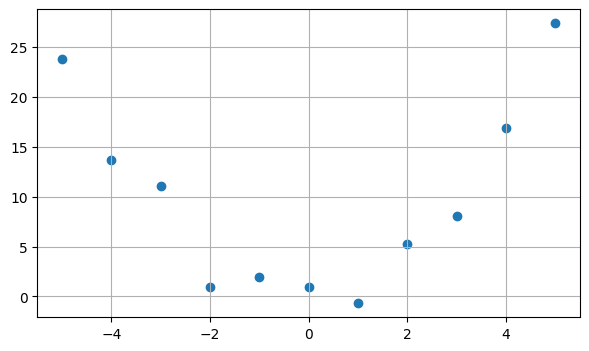

In [18]:
plt.figure(figsize=(7,4))
plt.scatter(x,y)
plt.grid(True)
plt.show()

# Design Matrix Polynomial

In [19]:
A_poly = np.column_stack([
    np.ones(len(x)),
    x,
    x**2
])

print(A_poly[:5])

[[ 1. -5. 25.]
 [ 1. -4. 16.]
 [ 1. -3.  9.]
 [ 1. -2.  4.]
 [ 1. -1.  1.]]


# 13. Polynomial Least Squares

In [20]:
coef_poly, *_ = np.linalg.lstsq(
    A_poly,
    y,
    rcond=None
)

print(coef_poly)

[-0.2548  0.253   1.0203]


In [21]:
y_hat = A_poly @ coef_poly

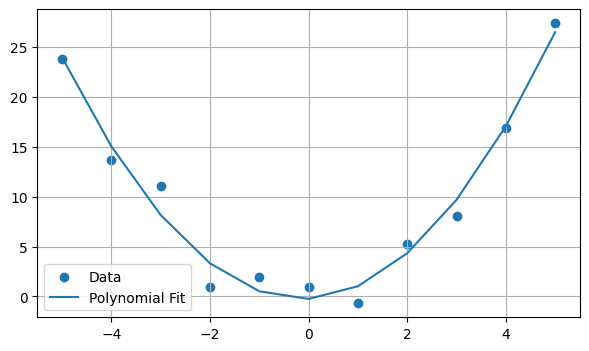

In [22]:
plt.figure(figsize=(7,4))

plt.scatter(
    x,
    y,
    label="Data"
)

plt.plot(
    x,
    y_hat,
    label="Polynomial Fit"
)

plt.legend()
plt.grid(True)
plt.show()

# Interpretasi

Model polynomial mampu menangkap pola non-linear yang tidak dapat ditangkap oleh regresi linear biasa.

# 14. Grid Search

Grid Search digunakan untuk mencari parameter terbaik.

Ide utamanya:

- mencoba banyak parameter
- menghitung error masing-masing
- memilih parameter dengan error terkecil

In [23]:
lambdas = np.arange(0,51,1)

errors = []

In [24]:
for lam in lambdas:

    coef = np.linalg.inv(
        A.T@A + lam*np.eye(A.shape[1])
    ) @ (A.T@b)

    pred = A @ coef

    err = np.mean(
        (b-pred)**2
    )

    errors.append(err)

# Visualisasi Grid Search

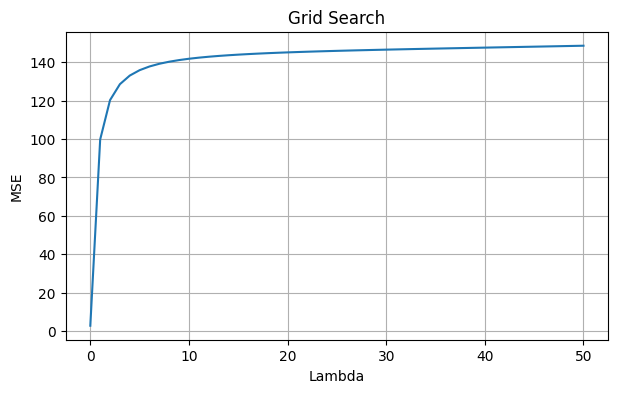

In [25]:
plt.figure(figsize=(7,4))

plt.plot(
    lambdas,
    errors
)

plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.title("Grid Search")
plt.grid(True)
plt.show()

In [26]:
best_index = np.argmin(errors)

best_lambda = lambdas[best_index]

print("Best lambda =", best_lambda)
print("Best MSE =", errors[best_index])

Best lambda = 0
Best MSE = 2.8273809523809725


best_index = np.argmin(errors)

best_lambda = lambdas[best_index]

print("Best lambda =", best_lambda)
print("Best MSE =", errors[best_index])

# Ringkasan Chapter 12

Pada chapter ini kita mempelajari:

- Least Squares Applications
- Prediksi dan regresi
- Residual
- SSE
- MSE
- R² Score
- Multicollinearity
- Ridge Regularization
- Polynomial Regression
- Grid Search

Chapter ini menunjukkan bagaimana konsep linear algebra berkembang menjadi berbagai teknik machine learning modern.